# Tópico 01 – Visualização de Dados [<img src="https://raw.githubusercontent.com/urielmoreirasilva/EST/main/aulas/T%C3%B3pico%2001%20%E2%80%93%20Visualiza%C3%A7%C3%A3o%20de%20Dados/images/colag_logo.svg" style="float: right; vertical-align: middle; width: 42px; height: 42px;">](https://colab.research.google.com/github/urielmoreirasilva/EST/blob/main/aulas/T%C3%B3pico%2001%20%E2%80%93%20Visualiza%C3%A7%C3%A3o%20de%20Dados/T%C3%B3pico%2001%20%E2%80%93%20Visualiza%C3%A7%C3%A3o%20de%20Dados.ipynb) [<img src="https://raw.githubusercontent.com/urielmoreirasilva/EST/main/aulas/T%C3%B3pico%2001%20%E2%80%93%20Visualiza%C3%A7%C3%A3o%20de%20Dados/images/github_logo.svg" style="float: right; margin-right: 12px; vertical-align: middle; width: 36px; height: 36px;">](https://github.com/urielmoreirasilva/EST/blob/main/aulas/T%C3%B3pico%2001%20%E2%80%93%20Visualiza%C3%A7%C3%A3o%20de%20Dados/T%C3%B3pico%2001%20%E2%80%93%20Visualiza%C3%A7%C3%A3o%20de%20Dados.ipynb)

Um pouco sobre como representar dados de maneira visual!

### Resultados Esperados
1. Aprender algumas ferramentas simples para exploração de dados.
1. Aprender os conceitos básicos de visualização de dados.
1. Aprender a manipular os DataFrames de `pandas` para produzir gráficos elementares.  

### Referências
- [CIT, Capítulo 7](https://inferentialthinking.com/)

Material adaptado do [DSC10 (UCSD)](https://dsc10.com/) por [Flavio Figueiredo (DCC-UFMG)](https://flaviovdf.io/fcd/) e [Uriel Silva (DEST-UFMG)](https://urielmoreirasilva.github.io)

In [1]:
# Importando Pandas e Numpy
import pandas as pd
import numpy as np

# Importando Matplotlib
import matplotlib.pyplot as plt
plt.style.use('ggplot')

# Importando alguns outros módulos para nos ajudar nas visualizações
from IPython.display import HTML, display, IFrame

## Visualização de dados

### Por que visualizar?

- Os computadores são melhores que os humanos para processar números, mas os humanos (em geral) são melhores para identificar padrões visuais.
- As visualizações nos permitem compreender rapidamente um grande volume de dados, facilitando a identificação de tendências e a comunicação de resultados.
- Existem _vários_ tipos de visualizações – neste tópico, veremos gráficos de dispersão, gráficos de linhas, gráficos de barras e histogramas.
- A escolha "certa" do método de visualização depende sempre do tipo de dado em questão!

## Prelúdio: um pouco de terminologia

### Indivíduos e variáveis

<center><img src="https://raw.githubusercontent.com/urielmoreirasilva/EST/main/aulas/T%C3%B3pico%2001%20%E2%80%93%20Visualiza%C3%A7%C3%A3o%20de%20Dados/images/ind-var.png" width = "90%"></center>

- <span style="color:#6d9eeb"><b>Indivíduo (linha):</b></span> Pessoa/lugar/coisa para a qual os dados são registrados. Também chamado de **observação**, ou _data point_.

- <span style="color:#ff9900"><b>Variável (coluna):</b></span> Característica observada para cada indivíduo. Também chamado de **recurso**, ou _feature_.

### Tipos de variáveis

Existem dois tipos principais de variáveis:

- **Numéricas**: Variáveis tais que seus valores permitam operações de aritmética básica.
- **Categóricas**: Variáveis cujos valores se enquadram em _categorias_, que podem ou não ter alguma _ordem_ entre elas.

### Exemplos de variáveis ​​numéricas

- Conjunto de dados: Salários dos jogadores da NBA. 🏀
    - Indivíduo: um jogador da NBA.
    - Variável: seu salário.

- Conjunto de dados: O rendimento no _box office_ de vários filmes. 🎬💰
    - Indivíduo: um filme.
    - Variável: o rendimento do filme no _box office_.

- Conjunto de dados: Doses de reforço de vacinas administradas por dia. 💉
    - Indivíduo: data de cada dia onde foram administradas as vacinas.
    - Variável: número de doses de reforço administradas em cada data.

### Exemplos de variáveis ​​​​categóricas

- Conjunto de dados: Gêneros de filmes. 🎬
    - Indivíduo: um filme.
    - Variável: seu gênero.

- Conjunto de dados: Códigos de Endereço Postais (CEPs). 🏠
    - Indivíduo: um habitante de uma cidade, ou região.
    - Variável: seu CEP.

Nota: apesar de serem reportados como números, os CEPs na verdade são categóricos (operações aritméticas básicas não têm sentido quando aplicadas aos CEPs).

- Conjunto de dados: Nível de experiência anterior em programação para alunos de Ciência de Dados 🧑‍🎓.
    - Indivíduo: um aluno.
    - Variável: seu nível de experiência anterior em programação, por ex.: "nenhum", "baixo", "médio" ou "alto".

Nota: essa é uma variável categórica _ordenada_!

### Exercício ✅

Qual destas **não** é uma variável numérica? Preencha a célula de texto abaixo com a resposta correspondente.

**A.** Gasto de combustível em quilômetros por litro.

**B.** Número de semestres de um curso na UFMG.

**C.** Período do curso na UFMG (primeiro, quinto, sétimo, etc).

**D.** Número de uma conta bancária.

**E.** Mais de uma das acima não são variáveis numéricas.

> ...

### Tipos de visualizações

O _tipo de visualização_ que criamos depende dos _tipos de variáveis_ ​​que estamos visualizando.

- **Gráfico de dispersão**: numérica vs. numérica.
- **Gráfico de linhas**: numérica "sequencial" (por exemplo no tempo) vs. numérica.
- **Gráfico de barras**: categórica vs. numérica.
- **Histograma**: numérica.

Veremos todos os esses tipos de gráficos nesse e no próximo tópico.

## Gráficos de dispersão

### Exemplo: os 50 atores de maior bilheteria

|Coluna |Conteúdo|
|----------|------------|
`'Actor'`|Nome do ator
`'Total Gross'`| Receita total bruta no _box office_, em milhões de dólares, de todos os filmes do ator
`'Number of Movies'`| O número total de filmes em que o ator esteve
`'Average per Movie'`| O total de receita bruta dividido pelo número total de filmes
`'#1 Movie'`| O filme de maior bilheteria em que o ator já esteve
`'Gross'`| Receita bruta de bilheteria interna, em milhões de dólares, do filme de maior bilheteria do ator

In [2]:
actors = pd.read_csv('https://raw.githubusercontent.com/urielmoreirasilva/EST/main/aulas/T%C3%B3pico%2001%20%E2%80%93%20Visualiza%C3%A7%C3%A3o%20de%20Dados/data/actors.csv').set_index('Actor')
actors

,Total Gross,Number of Movies,Average per Movie,#1 Movie,Gross
Actor,,,,,
Harrison Ford,4871.7,41,118.8,Star Wars: The Force Awakens,936.7
Samuel L. Jackson,4772.8,69,69.2,The Avengers,623.4
Morgan Freeman,4468.3,61,73.3,The Dark Knight,534.9
Tom Hanks,4340.8,44,98.7,Toy Story 3,415.0
"Robert Downey, Jr.",3947.3,53,74.5,The Avengers,623.4
Eddie Murphy,3810.4,38,100.3,Shrek 2,441.2
Tom Cruise,3587.2,36,99.6,War of the Worlds,234.3
Johnny Depp,3368.6,45,74.9,Dead Man's Chest,423.3
Michael Caine,3351.5,58,57.8,The Dark Knight,534.9


### Visualizando a relação entre duas variáveis

#### Qual é a relação entre `'Number of Movies'` e `'Total Gross'`?

Uma das maneiras de visualizar essa relação é através de um **diagrama de dispersão**, também conhecido como **gráfico de dispersão**:

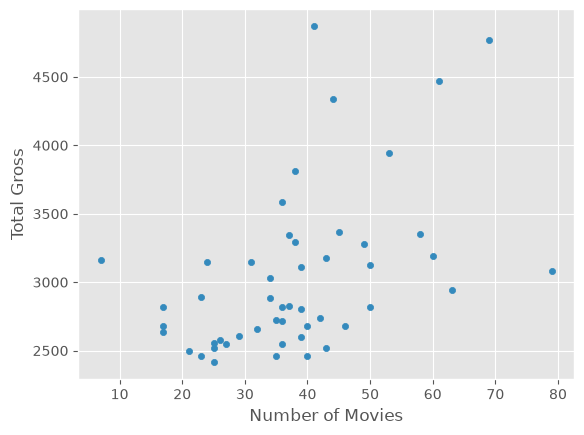

In [3]:
actors.plot(kind = 'scatter', x = 'Number of Movies', y = 'Total Gross');

- Os diagramas de dispersão (_scatter plots_) consistem de um arranjo dos valores de cada uma das duas colunas selecionadas de um `DataFrame` em pontos nas ordenadas $x$ e $y$ de um diagrama Cartesiano.
- Cada um dos pontos do diagrama de dispersão representam uma linha no nosso DataFrame. 
- Os diagramas de dispersão são muito úteis para visualizar a relação entre duas variáveis _​​numéricas_!

- Para criar um gráfico de dispersão a partir de um DataFrame `df` genérico com duas colunas numéricas `'x_column_for_horizontal'` e `'y_column_for_vertical'`, invocamos
```
df.plot(
    kind = 'scatter', 
    x = x_column_for_horizontal, 
    y = y_column_for_vertical
)
```

Nota: em geral coloamos um ponto e vírgula após uma chamada para `.plot`, para ocultar a saída de texto que acompanha a execução desse método.

<Axes: xlabel='Number of Movies', ylabel='Total Gross'>

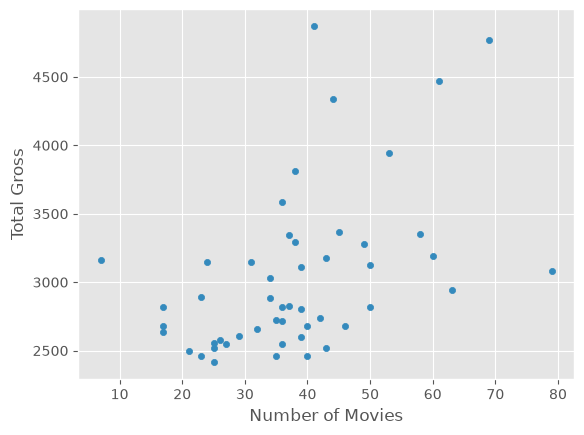

In [4]:
# O texto que aparece após a execução da célula abaixo não aparece quando colocamos ";" após chamarmos o método `.plot`
actors.plot(kind = 'scatter', x = 'Number of Movies', y = 'Total Gross')

Analisando o diagrama de dispersão acima, vemos uma associação positiva, mas bem dispersa, entre o número de filmes de um ator e o total de suas receitas no box office.

#### Qual é a relação entre `'Number of Movies'` e `'Average per Movie'`?

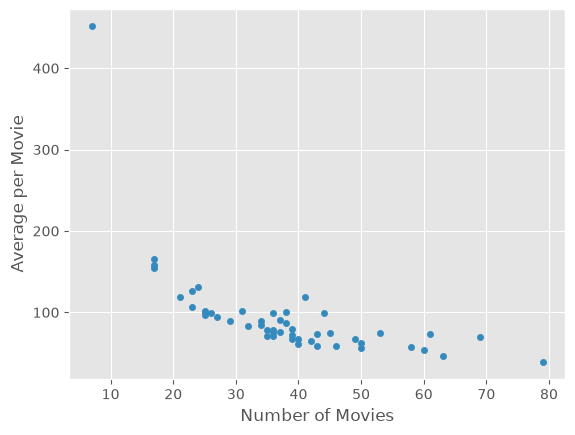

In [5]:
actors.plot(kind = 'scatter', x = 'Number of Movies', y = 'Average per Movie');

No gráfico acima, vamos associação _negativa_ entre as duas variáveis, e um _valor discrepante_ (_outlier_).

#### Qual ator esteve em 60 ou mais filmes?

In [6]:
actors[actors.get('Number of Movies') >= 60]

,Total Gross,Number of Movies,Average per Movie,#1 Movie,Gross
Actor,,,,,
Samuel L. Jackson,4772.8,69,69.2,The Avengers,623.4
Morgan Freeman,4468.3,61,73.3,The Dark Knight,534.9
Bruce Willis,3189.4,60,53.2,Sixth Sense,293.5
Robert DeNiro,3081.3,79,39.0,Meet the Fockers,279.3
Liam Neeson,2942.7,63,46.7,The Phantom Menace,474.5


#### E quem é o outlier no último diagrama?

Podemos identificar o outlier no diagrama anterior buscando pelo único ator que fez menos que 10 filmes.

In [7]:
actors[actors.get('Number of Movies') < 10]

,Total Gross,Number of Movies,Average per Movie,#1 Movie,Gross
Actor,,,,,
Anthony Daniels,3162.9,7,451.8,Star Wars: The Force Awakens,936.7


A média de receita no box office desse ator é bem alta!

#### Anthony Daniels

<center><img src='https://raw.githubusercontent.com/urielmoreirasilva/EST/main/aulas/T%C3%B3pico%2001%20%E2%80%93%20Visualiza%C3%A7%C3%A3o%20de%20Dados/images/c3po.png' width=200></center>

## Gráficos de linha 📉

### Exemplo: agregando filmes por ano

|Coluna| Conteúdo|
|------|-----------|
`'Year'`| Ano
`'Total Gross in Billions'`| Total bruto de bilheteria doméstica, em bilhões de dólares, de todos os filmes lançados no ano
`'Number of Movies'`| Número de filmes lançados no ano
`'#1 Movie'`| Filme de maior bilheteria no ano

In [8]:
movies_by_year = pd.read_csv('https://raw.githubusercontent.com/urielmoreirasilva/EST/main/aulas/T%C3%B3pico%2001%20%E2%80%93%20Visualiza%C3%A7%C3%A3o%20de%20Dados/data/movies_by_year.csv').set_index('Year')
movies_by_year

,Total Gross in Billions,Number of Movies,#1 Movie
Year,,,
2022,5.64,380,Top Gun: Maverick
2021,4.48,439,Spider-Man: No Way Home
2020,2.11,456,Bad Boys for Life
2019,11.36,910,Avengers: Endgame
2018,11.89,993,Black Panther
2017,11.08,854,Star Wars: Episode VIII - The Last Jedi
2016,11.38,855,Finding Dory
2015,11.15,845,Jurassic World
2014,10.37,849,Guardians of the Galaxy


- **Pergunta**: como o número de filmes lançados por ano mudou ao longo do tempo? 🤔

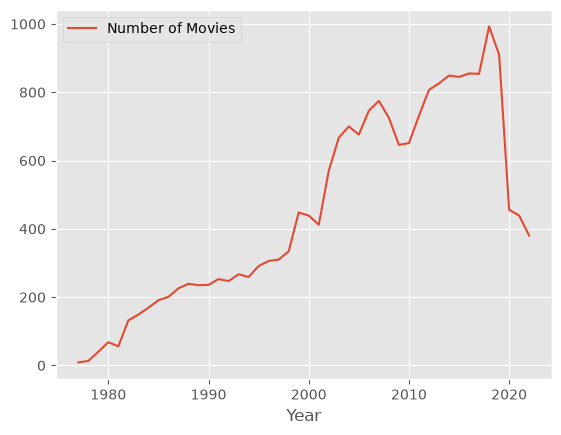

In [9]:
movies_by_year.plot(kind = 'line', y = 'Number of Movies');

### Gráficos de linha

- Os gráficos de linhas mostram tendências em variáveis ​​numéricas ao longo do tempo.

- Para criar um gráfico de linhas a partir de um DataFrame `df` genérico com duas colunas numéricas `'x_column_for_horizontal'` e `'y_column_for_vertical'`, invocamos

````python
df.plot(
    kind = 'line', 
    x = x_column_for_horizontal, 
    y = y_column_for_vertical
)
````

- **Dica**: quando quisermos que o eixo $x$ seja o índice do DataFrame, basta omitirmos o argumento `x =`!

Naturalmente, isso não funciona para gráficos de dispersão, mas funciona para a maioria dos outros tipos de gráficos.

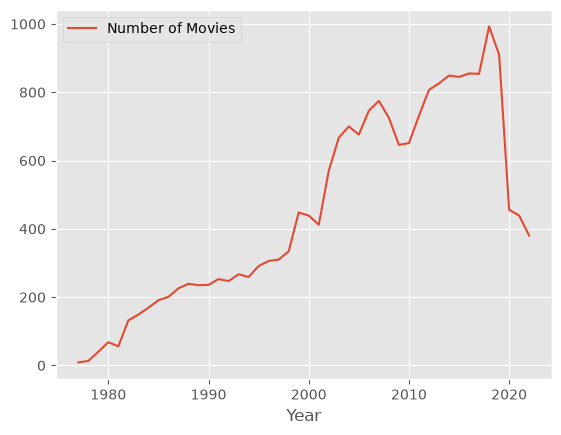

In [10]:
movies_by_year.plot(kind = 'line', y = 'Number of Movies');

#### Filtrando pelo índice

- Muitas vezes estamos interessados em _encurtar_ o horizonte de um gráfico de linhas.
- Isso pode nos ajudar a melhorar a visualização geral ou nos permitir discernir melhor algum detalhe específico, por exemplo.
- Para realizar esse encurtamento, basta invocar o plot após filtrar o DataFrame da maneira desejada por seu índice.

No exemplo acima, podemos criar um gráfico de linhas considerando apenas os anos de 2000 em diante:

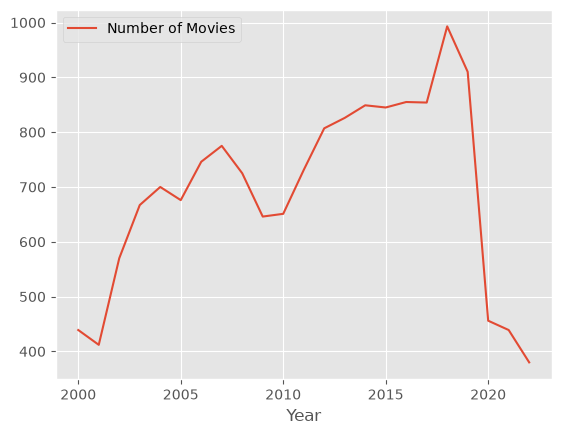

In [11]:
movies_by_year[movies_by_year.index >= 2000].plot(kind='line', y='Number of Movies');

Note agora que as quedas em torno de 2008 e 2020 estão muito mais aparentes!

#### Como as quedas em 2008 e 2020 afetaram o total bruto de bilheteria doméstica?

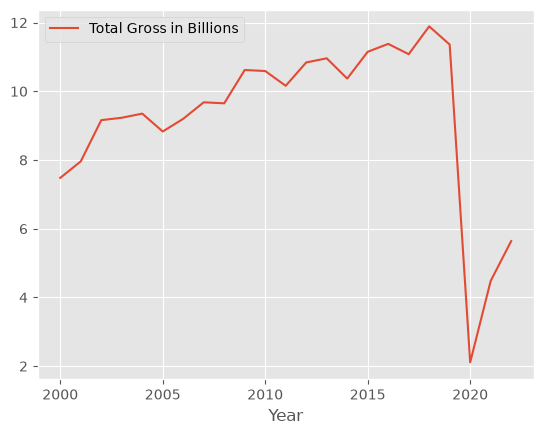

In [12]:
movies_by_year[movies_by_year.index >= 2000].plot(kind = 'line', y = 'Total Gross in Billions');

#### Curiosidade: qual foi o filme de maior bilheteria de 2016? 🐟

In [13]:
movies_by_year[movies_by_year.index == 2016]

,Total Gross in Billions,Number of Movies,#1 Movie
Year,,,
2016,11.38,855,Finding Dory


## Gráficos de barras 📊

### Exemplo: [200 músicas mais tocadas no Spotify dos EUA](https://spotifycharts.com/regional) (21/01/23)

In [14]:
charts = (pd.read_csv('https://raw.githubusercontent.com/urielmoreirasilva/EST/main/aulas/T%C3%B3pico%2001%20%E2%80%93%20Visualiza%C3%A7%C3%A3o%20de%20Dados/data/regional-us-daily-2023-01-21.csv')
          .set_index('rank')
          .get(['track_name', 'artist_names', 'streams', 'uri'])
         )
charts

,track_name,artist_names,streams,uri
rank,,,,
1,Flowers,Miley Cyrus,3356361,spotify:track:0yLdNVWF3Srea0uzk55zFn
2,Kill Bill,SZA,2479445,spotify:track:1Qrg8KqiBpW07V7PNxwwwL
3,Creepin' (with The Weeknd & 21 Savage),"Metro Boomin, The Weeknd, 21 Savage",1337320,spotify:track:2dHHgzDwk4BJdRwy9uXhTO
4,Superhero (Heroes & Villains) [with Future & C...,"Metro Boomin, Future, Chris Brown",1235285,spotify:track:0vjeOZ3Ft5jvAi9SBFJm1j
5,Rich Flex,"Drake, 21 Savage",1109704,spotify:track:1bDbXMyjaUIooNwFE9wn0N
...,...,...,...,...
196,"Burn, Burn, Burn",Zach Bryan,267772,spotify:track:5jfhLCSIFUO4ndzNRh4w4G
197,LET GO,Central Cee,267401,spotify:track:3zkyus0njMCL6phZmNNEeN
198,Major Distribution,"Drake, 21 Savage",266986,spotify:track:46s57QULU02Voy0Kup6UEb


### Motivação

Quantos streams as 10 músicas mais populares têm?

In [15]:
charts

,track_name,artist_names,streams,uri
rank,,,,
1,Flowers,Miley Cyrus,3356361,spotify:track:0yLdNVWF3Srea0uzk55zFn
2,Kill Bill,SZA,2479445,spotify:track:1Qrg8KqiBpW07V7PNxwwwL
3,Creepin' (with The Weeknd & 21 Savage),"Metro Boomin, The Weeknd, 21 Savage",1337320,spotify:track:2dHHgzDwk4BJdRwy9uXhTO
4,Superhero (Heroes & Villains) [with Future & C...,"Metro Boomin, Future, Chris Brown",1235285,spotify:track:0vjeOZ3Ft5jvAi9SBFJm1j
5,Rich Flex,"Drake, 21 Savage",1109704,spotify:track:1bDbXMyjaUIooNwFE9wn0N
...,...,...,...,...
196,"Burn, Burn, Burn",Zach Bryan,267772,spotify:track:5jfhLCSIFUO4ndzNRh4w4G
197,LET GO,Central Cee,267401,spotify:track:3zkyus0njMCL6phZmNNEeN
198,Major Distribution,"Drake, 21 Savage",266986,spotify:track:46s57QULU02Voy0Kup6UEb


In [16]:
charts.take(np.arange(10))

,track_name,artist_names,streams,uri
rank,,,,
1,Flowers,Miley Cyrus,3356361,spotify:track:0yLdNVWF3Srea0uzk55zFn
2,Kill Bill,SZA,2479445,spotify:track:1Qrg8KqiBpW07V7PNxwwwL
3,Creepin' (with The Weeknd & 21 Savage),"Metro Boomin, The Weeknd, 21 Savage",1337320,spotify:track:2dHHgzDwk4BJdRwy9uXhTO
4,Superhero (Heroes & Villains) [with Future & C...,"Metro Boomin, Future, Chris Brown",1235285,spotify:track:0vjeOZ3Ft5jvAi9SBFJm1j
5,Rich Flex,"Drake, 21 Savage",1109704,spotify:track:1bDbXMyjaUIooNwFE9wn0N
6,"Shakira: Bzrp Music Sessions, Vol. 53","Bizarrap, Shakira",1051226,spotify:track:4nrPB8O7Y7wsOCJdgXkthe
7,Just Wanna Rock,Lil Uzi Vert,998684,spotify:track:4FyesJzVpA39hbYvcseO2d
8,Anti-Hero,Taylor Swift,936166,spotify:track:0V3wPSX9ygBnCm8psDIegu
9,golden hour,JVKE,870031,spotify:track:5odlY52u43F5BjByhxg7wg


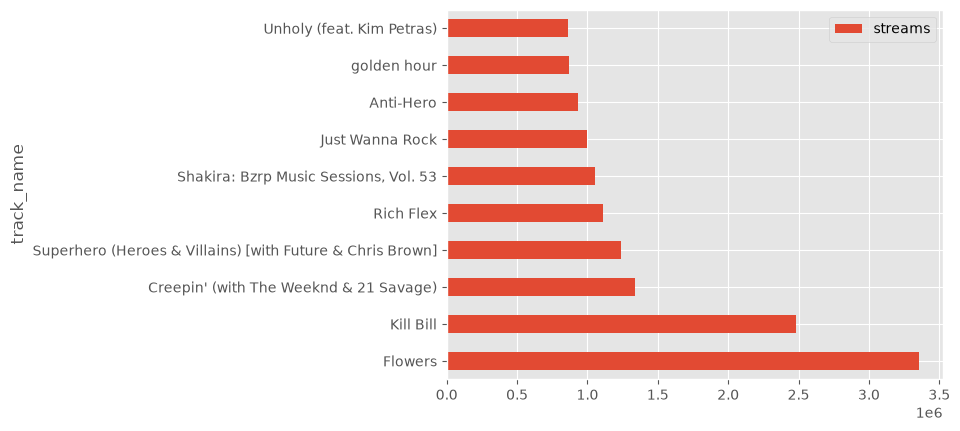

In [17]:
charts.take(np.arange(10)).plot(kind = 'barh', x = 'track_name', y = 'streams');

### Gráficos de barra

- Os gráficos de barras nos permitem visualizar a relação entre uma variável categórica e uma variável numérica.

- Para criar um gráfico de barras a partir de um DataFrame `df` genérico com uma coluna categórica `'categorical_column_name'` e uma coluna numérica `'numerical_column_name'`, invocamos

````python
df.plot(
    kind = 'barh', 
    x = categorical_column_name, 
    y = numerical_column_name
)
````

- O **"h"** em `'barh'` significa **"horizontal"**.
- Tipicamente, é mais fácil ler os rótulos quando o gráfico de barras é organizado de maneira horizontal.
- No gráfico anterior, definimos `y = 'Streams'`, ainda que os streams sejam medidos pelo comprimento do eixo $x$.
    - Isso ocorre porque em um gráfico de barras, _canonicamente_, a variável categórica está no eixo $x$ e a numérica no eixo $y$ – a opção `'barh'` apenas muda a "orientação" do gráfico de maneira a produzir uma visualização melhor (mais sobre isso abaixo). 

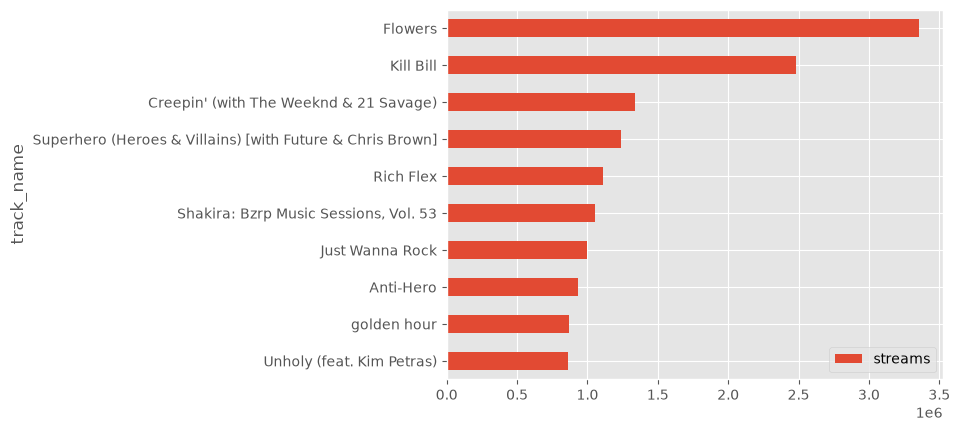

In [18]:
# As barras no gráfico abaixo aparecem na ordem "oposta" à que aparecem no DataFrame.
(charts
 .take(np.arange(10))
 .sort_values(by = 'streams')
 .plot(kind = 'barh', x = 'track_name', y = 'streams')
);

- Embora em geral na maior parte dos casos consigamos escolher parâmetros que nos ajudem a visualizar melhor nosso dados, a _espessura_ e o _espaçamento_ das barras em um gráfico de barras são _arbitrários_.
- Da mesma forma, a _ordem dos rótulos_ categóricos também é arbitrária.

#### Quantas músicas os 15 melhores artistas têm entre as 200 mais tocadas?

Para responder essa pergunta, primeiro vamos criar um DataFrame com uma única coluna que descreve o número de músicas entre as 200 melhores por artista.

Faremos isso utilizando o `.groupby` com `.size()`, agrupando por `'artist_names'`:

In [19]:
charts

,track_name,artist_names,streams,uri
rank,,,,
1,Flowers,Miley Cyrus,3356361,spotify:track:0yLdNVWF3Srea0uzk55zFn
2,Kill Bill,SZA,2479445,spotify:track:1Qrg8KqiBpW07V7PNxwwwL
3,Creepin' (with The Weeknd & 21 Savage),"Metro Boomin, The Weeknd, 21 Savage",1337320,spotify:track:2dHHgzDwk4BJdRwy9uXhTO
4,Superhero (Heroes & Villains) [with Future & C...,"Metro Boomin, Future, Chris Brown",1235285,spotify:track:0vjeOZ3Ft5jvAi9SBFJm1j
5,Rich Flex,"Drake, 21 Savage",1109704,spotify:track:1bDbXMyjaUIooNwFE9wn0N
...,...,...,...,...
196,"Burn, Burn, Burn",Zach Bryan,267772,spotify:track:5jfhLCSIFUO4ndzNRh4w4G
197,LET GO,Central Cee,267401,spotify:track:3zkyus0njMCL6phZmNNEeN
198,Major Distribution,"Drake, 21 Savage",266986,spotify:track:46s57QULU02Voy0Kup6UEb


In [20]:
songs_per_artist = charts.groupby('artist_names').size()
songs_per_artist

artist_names
21 Savage, Metro Boomin    1
80purppp                   1
A Boogie Wit da Hoodie     1
Arctic Monkeys             2
Arcángel, Bad Bunny        1
                          ..
XXXTENTACION               1
Yeat                       1
Zach Bryan                 4
d4vd                       2
Ñengo Flow, Bad Bunny      1
Length: 145, dtype: int64

Agora, utilizando `.sort_values` e `.take`, manteremos apenas os 15 melhores artistas:

In [21]:
top_15_artists = (songs_per_artist
                  .sort_values(ascending = False)
                  .take(np.arange(15)))
top_15_artists

artist_names
SZA                 11
Taylor Swift         8
Morgan Wallen        6
Drake, 21 Savage     5
The Weeknd           4
Zach Bryan           4
Mac DeMarco          3
J. Cole              3
Juice WRLD           2
Brent Faiyaz         2
Bad Bunny            2
Kanye West           2
Harry Styles         2
Childish Gambino     2
Lil Uzi Vert         2
dtype: int64

Antes de invocar `.plot(kind = 'barh', y = 'count')`, ordenaremos `top_15_artists` em ordem **crescente**.

Devemos fazer isso porque o Python _inverte_ a ordem das linhas ao criar barras em gráficos de barras horizontais.

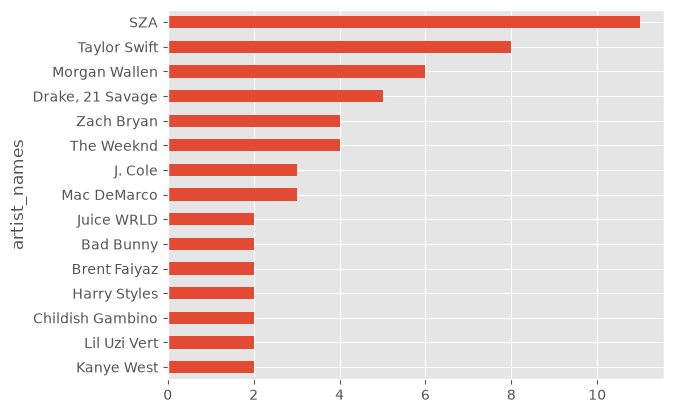

In [22]:
top_15_artists.sort_values().plot(kind = 'barh', y = 'count');

Note que no comando acima, omitimos a opção `x = 'artist_names'` sem nenhum problema porque como `top_15_artists` é uma `Series` e que já está indexada, o método `.plot` subentende que `x` é o seu índice. 

In [23]:
# Descomente e execute.
# top_15_artists.sort_values().plot(kind = 'barh', x = 'artist_names', y = 'count');

### Gráficos de barras verticais

- Para criar um gráfico de barras verticais, utilizamos `kind = 'bar'` ao invés de `kind = 'barh'`.

No nosso exemplo:

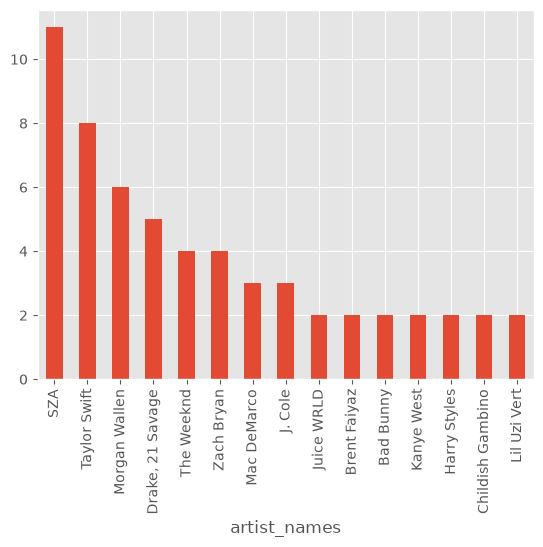

In [24]:
top_15_artists.plot(kind = 'bar', y = 'count');

- Aqui fica clara a razão do Python tomar a variável categórica como a variável correspondente ao eixo $x$, e a variável numérica como a variável correspondente ao eixo $y$.
- Ainda sobre esse ponto, reforçamos aqui a ideia de que `kind = 'barh'` apenas muda a orientação do tipo "canônico", que é `kind = 'bar'`.

#### Quantas vezes as músicas do The Weeknd foram tocadas?

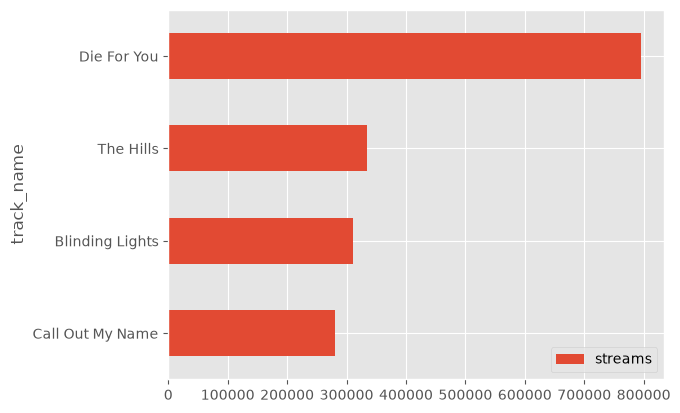

In [25]:
(charts
 [charts.get('artist_names') == 'The Weeknd']
 .sort_values('streams')
 .plot(kind='barh', x='track_name', y='streams')
);

Parece que não estamos incluindo todas as músicas do The Weeknd aqui...

E como resolvemos esse problema? 🤔

Resposta: Usando `.str.contains`!

In [26]:
weeknd = charts[charts.get('artist_names').str.contains('The Weeknd')]
weeknd

,track_name,artist_names,streams,uri
rank,,,,
3,Creepin' (with The Weeknd & 21 Savage),"Metro Boomin, The Weeknd, 21 Savage",1337320,spotify:track:2dHHgzDwk4BJdRwy9uXhTO
13,Die For You,The Weeknd,794924,spotify:track:2LBqCSwhJGcFQeTHMVGwy3
76,Stargirl Interlude,"The Weeknd, Lana Del Rey",372624,spotify:track:5gDWsRxpJ2lZAffh5p7K0w
78,Starboy,"The Weeknd, Daft Punk",361999,spotify:track:7MXVkk9YMctZqd1Srtv4MB
102,The Hills,The Weeknd,334354,spotify:track:7fBv7CLKzipRk6EC6TWHOB
110,I Was Never There,"The Weeknd, Gesaffelstein",328724,spotify:track:1cKHdTo9u0ZymJdPGSh6nq
128,Blinding Lights,The Weeknd,311176,spotify:track:0VjIjW4GlUZAMYd2vXMi3b
168,Call Out My Name,The Weeknd,281141,spotify:track:09mEdoA6zrmBPgTEN5qXmN


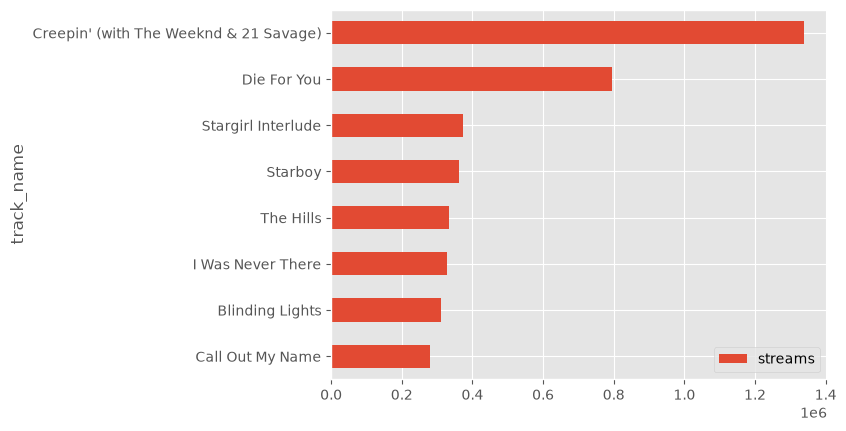

In [27]:
weeknd.sort_values('streams').plot(kind='barh', x='track_name', y='streams');

- As comparações do tipo `charts.get('artist_names') == 'The Weeknd'` filtram apenas pelas músicas cujo artista é **exatamente** `'The Weekend'`.
- Nos casos acima em que esse artista fez algum tipo de colaboração, isso não foi detectado!
- Utilizando o método `.str.contains` em `charts.get('artist_names').str.contains('The Weeknd')`, podemos captar tanto as músicas autoradas _apenas_ por `'The Weekend'`, mas também as que ele fez algum tipo de participação, isto é, autoradas _não somente_ por ele.

### Exercício ✅

Modifique a célula de código abaixo para exibir a quantidade de streams das músicas de algum artista de sua preferência.

<u> Dica</u>: tente utilizar apenas *parte* do nome do artista e verifique como o método `.str.contains` lida com isso! 

In [28]:
# ## Descomente e execute!
# artist = charts[charts.get('artist_names').str.contains('...')]
# artist

In [29]:
# ## Descomente e execute!
# artist.sort_values('streams').plot(kind='barh', x='track_name', y='streams');

#### Uma demonstração interessante 🎵

In [30]:
# Execute essa célula, mas por enquanto não se preocupe com o que ela faz.
def show_spotify(uri):
    code = uri[uri.rfind(':')+1:]
    src = f"https://open.spotify.com/embed/track/{code}"
    width = 400
    height = 75
    display(IFrame(src, width, height))

- Vamos encontrar o URI (_Unique Resource Identifier_) de uma música que nos interessa!

In [31]:
charts

,track_name,artist_names,streams,uri
rank,,,,
1,Flowers,Miley Cyrus,3356361,spotify:track:0yLdNVWF3Srea0uzk55zFn
2,Kill Bill,SZA,2479445,spotify:track:1Qrg8KqiBpW07V7PNxwwwL
3,Creepin' (with The Weeknd & 21 Savage),"Metro Boomin, The Weeknd, 21 Savage",1337320,spotify:track:2dHHgzDwk4BJdRwy9uXhTO
4,Superhero (Heroes & Villains) [with Future & C...,"Metro Boomin, Future, Chris Brown",1235285,spotify:track:0vjeOZ3Ft5jvAi9SBFJm1j
5,Rich Flex,"Drake, 21 Savage",1109704,spotify:track:1bDbXMyjaUIooNwFE9wn0N
...,...,...,...,...
196,"Burn, Burn, Burn",Zach Bryan,267772,spotify:track:5jfhLCSIFUO4ndzNRh4w4G
197,LET GO,Central Cee,267401,spotify:track:3zkyus0njMCL6phZmNNEeN
198,Major Distribution,"Drake, 21 Savage",266986,spotify:track:46s57QULU02Voy0Kup6UEb


In [32]:
favorite_song = 'Blinding Lights'

In [33]:
song_uri = (charts
            [charts.get('track_name') == favorite_song]
            .get('uri')
            .iloc[0])
song_uri

'spotify:track:0VjIjW4GlUZAMYd2vXMi3b'

Agora, veja o que acontece! 🎶

In [34]:
show_spotify(song_uri)

## Visualizações "ruins"

- Conforme mencionado anteriormente, as visualizações nos permitem identificar facilmente tendências e comunicar nossos resultados de maneira mais informativa a outras pessoas.
- Porém, algumas visualizações podem tornar os padrões nos dados _mais difíceis_ de ver!
- Os elementos adicionais (e na maioria das vezes desnecessários) que dificultam visualizações são popularmente conhecidos como ["chart junk"](https://eagereyes.org/criticism/chart-junk-considered-useful-after-all).

Além do chart junk, algumas manipulações clássicas dos gráficos incluem distorções dos eixos/unidades, inclusão de elementos de comparação relativa com tamanhos incorretos, etc. 

Seguem abaixo alguns exemplos de visualizações "ruins":

<left>
    <img src = "https://raw.githubusercontent.com/urielmoreirasilva/EST/main/aulas/T%C3%B3pico%2001%20%E2%80%93%20Visualiza%C3%A7%C3%A3o%20de%20Dados/images/usefuljunk-monster.jpg" width = "50%">
</left>    

<left>
    <img src = "https://raw.githubusercontent.com/urielmoreirasilva/EST/main/aulas/T%C3%B3pico%2001%20%E2%80%93%20Visualiza%C3%A7%C3%A3o%20de%20Dados/images/average_height.png" width = "50%">
</left>

<left>
    <img src = "https://raw.githubusercontent.com/urielmoreirasilva/EST/main/aulas/T%C3%B3pico%2001%20%E2%80%93%20Visualiza%C3%A7%C3%A3o%20de%20Dados/images/bananas.png" width = "50%">
</left>

<left>
    <img src = "https://raw.githubusercontent.com/urielmoreirasilva/EST/main/aulas/T%C3%B3pico%2001%20%E2%80%93%20Visualiza%C3%A7%C3%A3o%20de%20Dados/images/weather.png" width = "50%">
</left>

## Resumo

- As visualizações facilitam a extração de padrões de conjuntos de dados, e a comunicar esses padrões de maneira clara e intuitiva.
- Existem dois tipos principais de variáveis: **categóricas** e **numéricas**.
- Os tipos de variáveis ​​que estamos visualizando usualmente informam nossa escolha de qual tipo de visualização usar.
- Nesse tópico, introduzimos os **gráficos de dispersão**, **gráficos de linhas** e os **gráficos de barras**.